In [2]:
import random
from collections import defaultdict
from sentence_transformers import SentenceTransformer, SentencesDataset, models, losses, InputExample
from sentence_transformers.losses import TripletLoss
from sentence_transformers.readers import LabelSentenceReader, InputExample
from torch.utils.data import DataLoader
import os
import sys
import numpy as np
import json
import pandas as pd
from sentence_transformers import datasets
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
import torch
from scipy.spatial import distance
from sklearn import metrics
from sklearn.metrics import pairwise_distances
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt
# from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
from scipy.spatial.distance import cosine
from transformers import AutoModel, AutoTokenizer
import seaborn as sns
import re


In [ ]:
df = pd.read_csv('data/filtered_vegan.csv') #20k tweets
df

In [5]:
unique_df = df.drop_duplicates(subset=['text'])
unique_df.reset_index(inplace=True)

In [5]:
# Counting unique rows directly
unique_count = df.drop_duplicates(subset=['text']).shape[0]
unique_count

18901

In [6]:
def remove_links(text):
    # Define a regular expression pattern to match URLs
    url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'

    # Remove URLs from the text
    text_without_links = re.sub(url_pattern, '', text)

    return text_without_links

def remove_line_breaks_and_links(text):
    # Remove line breaks
    text_without_line_breaks = re.sub(r'\n{2,}', '\n', text)
    removew_leading_indent = re.sub(r'\n\s+', '\n', text_without_line_breaks)  # Remove leading indentation
    
    # Remove links
    text_without_links = remove_links(removew_leading_indent)

    return text_without_links


In [7]:
cleaned_text = []
for index, row in unique_df.iterrows():
    text = row['text']
    cleaned_text.append(remove_line_breaks_and_links(text).strip())

In [8]:
unique_df['proc_text'] = cleaned_text

/var/folders/_x/vl17h_s11wb7_fsln60k_3ww0000gn/T/ipykernel_6384/740874376.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_df['proc_text'] = cleaned_text


In [9]:
# Step 1: Preprocess the text data
def preprocess_text(text):
    text = text.lower()
    return text

unique_df['proc_text'] = unique_df['proc_text'].apply(preprocess_text)

/var/folders/_x/vl17h_s11wb7_fsln60k_3ww0000gn/T/ipykernel_6384/364984474.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_df['proc_text'] = unique_df['proc_text'].apply(preprocess_text)


In [10]:
len(pd.unique(unique_df['name']))
#unique_df.columns

275

In [11]:
unique_df

,index,name,uid,location,description,tweet_id,created_at,text,len,likes,retweets,proc_text
0,0,1Kimsey,1.076630e+08,In your head Zombie,"Baking, speed reading, knife throwing, bird wa...",1.338991e+18,2020-12-15 23:34:28,RT @Robert0Guiscard: Love them don’t eat them ...,83.0,0.0,101.0,rt @robert0guiscard: love them don’t eat them ...
1,1,1nonlyrhea,1.166039e+18,"Corpus Christi, TX",Eat a fucking 40 clip,1.320094e+18,2020-10-24 20:06:05,RT @jacobccfisher: so excited to try these new...,96.0,0.0,6004.0,rt @jacobccfisher: so excited to try these new...
2,2,1nonlyrhea,1.166039e+18,"Corpus Christi, TX",Eat a fucking 40 clip,1.311808e+18,2020-10-01 23:20:12,RT @funkyfroot: Want to win a bag of cannabis ...,140.0,0.0,2348.0,rt @funkyfroot: want to win a bag of cannabis ...
3,3,1nonlyrhea,1.166039e+18,"Corpus Christi, TX",Eat a fucking 40 clip,1.296234e+18,2020-08-19 23:54:29,RT @amor_valeriaa: remember: even vegetarian a...,89.0,0.0,119148.0,rt @amor_valeriaa: remember: even vegetarian a...
4,4,1nonlyrhea,1.166039e+18,"Corpus Christi, TX",Eat a fucking 40 clip,1.271950e+18,2020-06-13 23:39:03,RT @FATHERJAWSH: this vegan shit easy 💪🏾😤 http...,65.0,0.0,21112.0,rt @fatherjawsh: this vegan shit easy 💪🏾😤
...,...,...,...,...,...,...,...,...,...,...,...,...
18896,19995,GreenBay_UK,7.151814e+17,"London, England",UK's Vegan Supermarket🌱🇬🇧 All your favourites...,9.975675e+17,2018-05-18 20:00:05,Liquid smoke gives your food a wonderful smoke...,195.0,1.0,0.0,liquid smoke gives your food a wonderful smoke...
18897,19996,GreenBay_UK,7.151814e+17,"London, England",UK's Vegan Supermarket🌱🇬🇧 All your favourites...,9.975524e+17,2018-05-18 19:00:09,Everything in balance! 🙌 #vegan #balance #life...,96.0,5.0,1.0,everything in balance! 🙌 #vegan #balance #life...
18898,19997,GreenBay_UK,7.151814e+17,"London, England",UK's Vegan Supermarket🌱🇬🇧 All your favourites...,9.973561e+17,2018-05-18 06:00:10,"Why veganism is easier than you think, and how...",137.0,7.0,6.0,"why veganism is easier than you think, and how..."
18899,19998,GreenBay_UK,7.151814e+17,"London, England",UK's Vegan Supermarket🌱🇬🇧 All your favourites...,9.972052e+17,2018-05-17 20:00:13,"Anyone else dream about work? 😴 😅 Like, all th...",91.0,0.0,0.0,"anyone else dream about work? 😴 😅 like, all th..."


In [12]:
import pandas as pd
import numpy as np
import umap
import hdbscan
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import TruncatedSVD
from hdbscan import validity
from scipy.sparse import csr_matrix


# # Step 1: Preprocess the text data
# def preprocess_text(text):
#     text = text.lower()
#     return text

# unique_df['proc_text'] = unique_df['proc_text'].apply(preprocess_text)

# Step 2: Convert the text data into numerical form using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(unique_df['proc_text'])  # Keep X as a sparse matrix

# Step 3: Normalize the data using MaxAbsScaler (works with sparse matrices)
scaler = MaxAbsScaler()
X_normalized = scaler.fit_transform(X)

# Step 4: Reduce the dimensionality using TruncatedSVD
# TruncatedSVD works well with sparse matrices
svd = TruncatedSVD(n_components=100, random_state=42)  # Adjust n_components based on memory availability
X_reduced = svd.fit_transform(X_normalized)

# Step 5: Define the searchClusterParameters function
def searchClusterParameters(embeddings, hdbParamdist):
    umapArgs = {'n_neighbors': 15, 'n_components': 5, 'metric': 'cosine'}
    bestUmapModel = None
    bestHDBModel = None
    bestScore = -1
    bestParameters = {}

    for minClusterSize in hdbParamdist["min_cluster_size"]:
        umapArgs['n_neighbors'] = minClusterSize
        umapModel = umap.UMAP(**umapArgs, random_state=11).fit(embeddings)  # UMAP on reduced embeddings
        
        for minSamples in hdbParamdist["min_samples"]:
            for clusterSelectionMethod in hdbParamdist["cluster_selection_method"]:
                for metric in hdbParamdist["metric"]:
                    hdb = hdbscan.HDBSCAN(min_cluster_size=minClusterSize, min_samples=minSamples,
                                          cluster_selection_method=clusterSelectionMethod, metric=metric,
                                          gen_min_span_tree=True).fit(umapModel.embedding_)
                    # DBCV score
                    score = hdb.relative_validity_
                    # if we got a better DBCV, store it, the model and their parameters
                    if score > bestScore:
                        bestScore = score
                        bestParameters = {'min_cluster_size': minClusterSize, 
                                          'min_samples':  minSamples, 
                                          'cluster_selection_method': clusterSelectionMethod,
                                          'metric': metric}
                        bestUmapModel = umapModel
                        bestHDBModel = hdb

    return bestUmapModel, bestHDBModel, bestScore, bestParameters

# Step 6: Define HDBSCAN parameter distribution and normalize embeddings
numDataPoints = X_reduced.shape[0]
hdbParamdist = ,
                'min_cluster_size': [15, int(np.ceil(.05*numDataPoints)), int(np.ceil(.1*numDataPoints)), int(np.ceil(.2*numDataPoints)), int(np.ceil(.25*numDataPoints))],  
                'cluster_selection_method' : ['eom'],
                'metric' : ['euclidean'] }

# Search for best parameters
umapModel, hdbModel, bestScore, bestParameters = searchClusterParameters(X_reduced, hdbParamdist)

# Add the best cluster labels to the DataFrame
if hdbModel is not None:
    unique_df['cluster'] = hdbModel.labels_
else:
    unique_df['cluster'] = -1

# Display the DataFrame with cluster labels and the best DBCV score
print(f"Best parameters: {bestParameters}")
print(f"Best DBCV score: {bestScore}")


Best parameters: {'min_cluster_size': 15, 'min_samples': 3, 'cluster_selection_method': 'eom', 'metric': 'euclidean'}
Best DBCV score: 0.35034881231284576


/var/folders/_x/vl17h_s11wb7_fsln60k_3ww0000gn/T/ipykernel_6384/2233915429.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_df['cluster'] = hdbModel.labels_


/var/folders/_x/vl17h_s11wb7_fsln60k_3ww0000gn/T/ipykernel_6384/1152469961.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_df['cluster'] = hdbModel.labels_


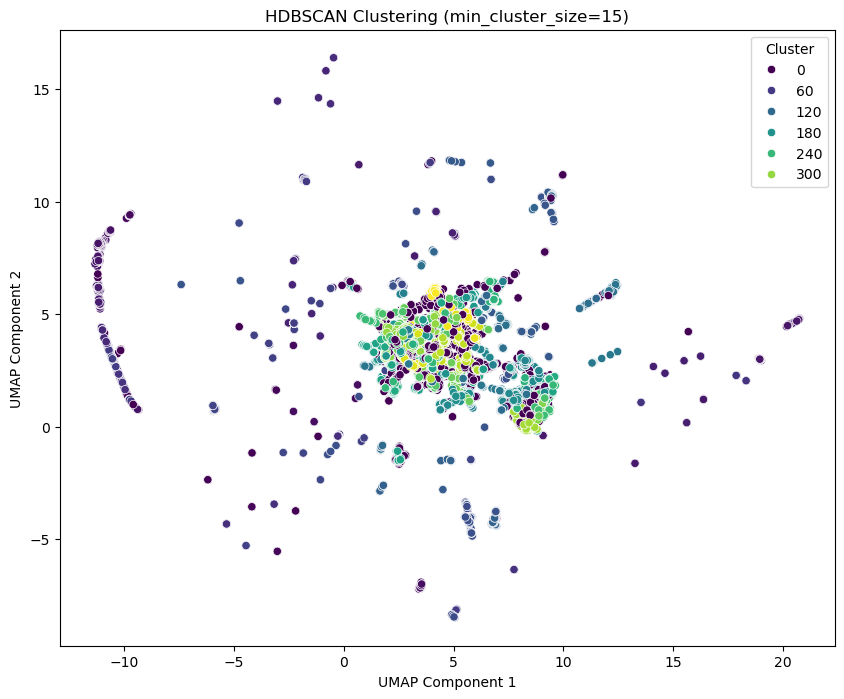

In [13]:
# Step 6: Plot the clustering result
if hdbModel is not None:
    # Add the best cluster labels to the DataFrame
    unique_df['cluster'] = hdbModel.labels_
    
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=umapModel.embedding_[:, 0], y=umapModel.embedding_[:, 1], hue=hdbModel.labels_, palette='viridis')
    plt.title(f"HDBSCAN Clustering (min_cluster_size={bestParameters['min_cluster_size']})")
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')
    plt.legend(title='Cluster')
    plt.show()
else:
    print("No valid clusters found.")

In [14]:
# Determine the number of clusters after HDBSCAN
if hdbModel is not None:
    # Add the best cluster labels to the DataFrame
    unique_df['cluster'] = hdbModel.labels_
    
    # Determine the number of clusters (excluding noise points labeled as -1)
    labels = hdbModel.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    print(f"Number of clusters: {n_clusters}")
else:
    print("No valid clusters found.")

# Display the DataFrame with cluster labels and the best DBCV score
print(f"Best parameters: {bestParameters}")
print(f"Best DBCV score: {bestScore}")
#print(df)

Number of clusters: 359
Best parameters: {'min_cluster_size': 15, 'min_samples': 3, 'cluster_selection_method': 'eom', 'metric': 'euclidean'}
Best DBCV score: 0.35034881231284576


/var/folders/_x/vl17h_s11wb7_fsln60k_3ww0000gn/T/ipykernel_6384/3797818392.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_df['cluster'] = hdbModel.labels_


In [15]:
from sklearn.metrics.pairwise import euclidean_distances
# Step 6: Find the top-5 closest elements to the centroid for each cluster
def find_top_k_closest_points(data, centroid, k):
    distances = euclidean_distances(data, [centroid]).flatten()
    closest_indices = np.argsort(distances)[:k]
    return closest_indices

new_df_list = []

if hdbModel is not None:
    # Add the best cluster labels to the DataFrame
    unique_df['cluster'] = hdbModel.labels_

    cluster_labels = hdbModel.labels_
    unique_labels = set(cluster_labels) - {-1}  # Exclude noise points
    k = 5  # Number of closest points to find
    
    for cluster in unique_labels:
        cluster_indices = np.where(cluster_labels == cluster)[0]
        cluster_points = umapModel.embedding_[cluster_indices]
        centroid = cluster_points.mean(axis=0)
        
        # Find top-5 closest points to the centroid
        closest_indices = find_top_k_closest_points(cluster_points, centroid, k)
        closest_points_indices = cluster_indices[closest_indices]
        
        # Extract the top-5 closest points to a new DataFrame
        new_df_list.append(unique_df.iloc[closest_points_indices])

    # Concatenate the list of DataFrames into a single DataFrame
    new_df = pd.concat(new_df_list, ignore_index=True)
else:
    print("No valid clusters found.")
    new_df = pd.DataFrame()  # Empty DataFrame

# Display the new DataFrame with clusters and top-5 closest elements
print(new_df)

/var/folders/_x/vl17h_s11wb7_fsln60k_3ww0000gn/T/ipykernel_6384/4139434290.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_df['cluster'] = hdbModel.labels_


      index             name           uid      location  \
0      3940  BeautySkinYourN  7.992584e+17           NaN   
1      4246  BeautySkinYourN  7.992584e+17           NaN   
2      4000  BeautySkinYourN  7.992584e+17           NaN   
3      4101  BeautySkinYourN  7.992584e+17           NaN   
4      3789  BeautySkinYourN  7.992584e+17           NaN   
...     ...              ...           ...           ...   
1790   7021      CFreeChurch  9.320417e+17     Universal   
1791  11402       CreateSust  9.955517e+07  Plano, Texas   
1792   1223          Agatheg  2.118419e+07           NaN   
1793    603     ATXShadowcat  1.607140e+09    Austin, TX   
1794  11353       CreateSust  9.955517e+07  Plano, Texas   

                                            description      tweet_id  \
0     Daily Tips from our Nurses, Dietitians, Aesthe...  1.284103e+18   
1     Daily Tips from our Nurses, Dietitians, Aesthe...  1.279211e+18   
2     Daily Tips from our Nurses, Dietitians, Aesthe...  1.2

In [16]:
# new_df.to_csv('data/top5_cluster_hdbscan_vegan_iter1.csv') 
new_df.to_csv('data/top5_cluster_hdbscan_vegan_iter1_new.csv') 
